# Algoritmos Genéticos - Asesorando inversiones

En este notebook se resuelve el problema de inversión en bonos usando:

1. La solución de la bibliografía.
2. La solución con la librería DEAP.
3. Una comparación entre ambas técnicas.

**Capital elegido para esta práctica:** 5000

In [3]:
from random import random, randint, sample
import random as pyrandom
from collections import namedtuple

import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Semilla para reproducibilidad
pyrandom.seed(42)
np.random.seed(42)

# Estructura de cada bono
Inversion = namedtuple("Inversion", "precio cantidad rendim")



etiquetas = ["A", "B", "C", "D", "E"]

inversiones = [
    Inversion(500, 5, 0.15),
    Inversion(700, 6, 0.05),
    Inversion(300, 10, 0.03),
    Inversion(800, 3, 0.10),
    Inversion(400, 7, 0.10)
]


capital = 5000

# Parámetros del AG
individuos = 20
generaciones = 1000

In [5]:
# Calcula el capital invertido por un individuo
def capitalInvertido(individuo):
    return sum(map(lambda x, y: x * y.precio, individuo, inversiones))


# Calcula el rendimiento obtenido por un individuo
def rendimiento(individuo):
    return sum(map(lambda x, y: x * y.precio * y.rendim, individuo, inversiones))


# Si un individuo gasta más capital del disponible,
# se eliminan aleatoriamente inversiones hasta que se ajusta al capital
def ajustaCapital(individuo):
    ajustado = individuo[:]

    while capitalInvertido(ajustado) > capital:
        pos = randint(0, len(ajustado) - 1)
        if ajustado[pos] > 0:
            ajustado[pos] -= 1

    return ajustado

In [6]:
# Crea un individuo al azar, en este caso una selección de inversiones
# que no excedan el capital disponible y respeten la cantidad máxima de bonos
def creaIndividuo(inversiones, capital):
    individuo = [0] * len(inversiones)

    while capitalInvertido(individuo) < capital:
        eleccion = randint(0, len(inversiones) - 1)

        # Solo agrega si no rebasa la cantidad disponible
        if individuo[eleccion] < inversiones[eleccion].cantidad:
            individuo[eleccion] += 1

        # Si ya se llegó al máximo en todos los bonos, se sale
        if all(individuo[i] == inversiones[i].cantidad for i in range(len(inversiones))):
            break

    return ajustaCapital(individuo)


# Crea un nuevo individuo cruzando otros dos
def cruza(poblacion, posiciones):
    L = len(poblacion[0])

    # Toma los genes del primer progenitor
    hijo = poblacion[posiciones[0]][:]

    # Luego toma al azar un segmento del segundo progenitor
    inicio = randint(0, L - 1)
    fin = randint(inicio + 1, L)
    hijo[inicio:fin] = poblacion[posiciones[1]][inicio:fin]

    return ajustaCapital(hijo)


# Aplica mutaciones a un individuo según una tasa dada
def muta(individuo, tasaMutacion):
    mutado = []

    for i in range(len(individuo)):
        if random() > tasaMutacion:
            mutado.append(individuo[i])
        else:
            mutado.append(randint(0, inversiones[i].cantidad))

    return ajustaCapital(mutado)

In [7]:
# Hace evolucionar el sistema durante un número de generaciones
def evoluciona(poblacion, generaciones):
    # Ordena la población inicial por rendimiento producido
    poblacion.sort(key=lambda x: rendimiento(x))

    N = len(poblacion)
    tasaMutacion = 0.01

    # Genera una lista del tipo [0,1,1,2,2,2,3,3,3,3,...]
    # para representar probabilidades de reproducirse de cada individuo
    reproduccion = [x for x in range(N) for y in range(x + 1)]

    historial_mejor = []
    historial_promedio = []

    for _ in range(generaciones):
        historial_mejor.append(rendimiento(poblacion[-1]))
        historial_promedio.append(np.mean([rendimiento(ind) for ind in poblacion]))

        # Se generan N-1 nuevos individuos cruzando los existentes
        padres = sample(reproduccion, 2)
        while padres[0] == padres[1]:
            padres = sample(reproduccion, 2)

        hijos = [cruza(poblacion, padres) for _ in range(N - 1)]

        # Se aplican mutaciones con cierta probabilidad
        hijos = [muta(x, tasaMutacion) for x in hijos]

        # Se añade el mejor individuo de la población anterior (elitismo)
        hijos.append(poblacion[-1][:])
        poblacion = hijos

        # Se ordenan los individuos por rendimiento
        poblacion.sort(key=lambda x: rendimiento(x))

    historial_mejor.append(rendimiento(poblacion[-1]))
    historial_promedio.append(np.mean([rendimiento(ind) for ind in poblacion]))

    # Devuelve el mejor individuo encontrado
    return poblacion[-1], historial_mejor, historial_promedio

In [8]:
poblacion = [creaIndividuo(inversiones, capital) for _ in range(individuos)]

mejor_biblio, hist_mejor_biblio, hist_prom_biblio = evoluciona(poblacion, generaciones)

print("=== SOLUCIÓN DE LA BIBLIOGRAFÍA ===")
print("Mejor individuo encontrado:", mejor_biblio)
print("Capital invertido:", capitalInvertido(mejor_biblio))
print("Rendimiento total:", rendimiento(mejor_biblio))

print("\nCantidad de bonos por tipo:")
for nombre, cantidad in zip(etiquetas, mejor_biblio):
    print(f"{nombre}: {cantidad}")

=== SOLUCIÓN DE LA BIBLIOGRAFÍA ===
Mejor individuo encontrado: [5, 0, 0, 1, 4]
Capital invertido: 4900
Rendimiento total: 615.0

Cantidad de bonos por tipo:
A: 5
B: 0
C: 0
D: 1
E: 4


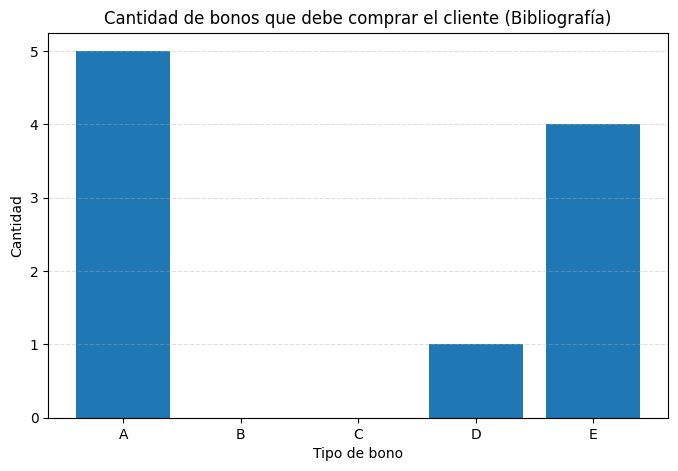

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(etiquetas, mejor_biblio)
plt.title("Cantidad de bonos que debe comprar el cliente (Bibliografía)")
plt.xlabel("Tipo de bono")
plt.ylabel("Cantidad")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

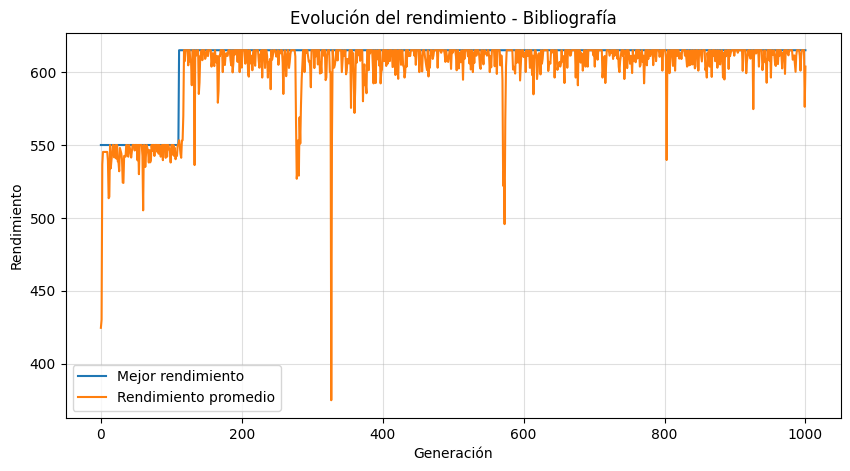

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(hist_mejor_biblio, label="Mejor rendimiento")
plt.plot(hist_prom_biblio, label="Rendimiento promedio")
plt.title("Evolución del rendimiento - Bibliografía")
plt.xlabel("Generación")
plt.ylabel("Rendimiento")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

In [21]:
%pip install deap

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from deap import base, creator, tools

In [ ]:
if "FitnessMaxInv" not in creator.__dict__:
    creator.create("FitnessMaxInv", base.Fitness, weights=(1.0,))

if "IndividualInv" not in creator.__dict__:
    creator.create("IndividualInv", list, fitness=creator.FitnessMaxInv)

In [ ]:
def reparar(individuo):
    # Ajuste por límites de cantidad
    for i, inv in enumerate(inversiones):
        if individuo[i] < 0:
            individuo[i] = 0
        elif individuo[i] > inv.cantidad:
            individuo[i] = inv.cantidad

    # Ajuste por capital
    while capitalInvertido(individuo) > capital:
        posiciones_validas = [i for i, q in enumerate(individuo) if q > 0]
        if not posiciones_validas:
            break
        pos = pyrandom.choice(posiciones_validas)
        individuo[pos] -= 1

    return individuo


def crear_individuo_deap():
    ind = creator.IndividualInv([pyrandom.randint(0, inv.cantidad) for inv in inversiones])
    reparar(ind)
    return ind


def evaluar_deap(individuo):
    reparar(individuo)
    return (rendimiento(individuo),)


def mutacion_deap(individuo, indpb=0.2):
    for i, inv in enumerate(inversiones):
        if pyrandom.random() < indpb:
            individuo[i] = pyrandom.randint(0, inv.cantidad)

    reparar(individuo)
    return (individuo,)

In [ ]:
toolbox = base.Toolbox()

toolbox.register("individual", crear_individuo_deap)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluar_deap)
toolbox.register("select", tools.selRoulette)
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", mutacion_deap, indpb=0.2)

In [ ]:
def ejecutar_deap(n_individuos=20, n_generaciones=1000, pc=0.7, pm=0.2):
    poblacion = toolbox.population(n=n_individuos)

    for ind in poblacion:
        ind.fitness.values = toolbox.evaluate(ind)

    historial_mejor = []
    historial_promedio = []

    for _ in range(n_generaciones):
        elite = tools.selBest(poblacion, 1)[0]
        hijos = list(map(toolbox.clone, toolbox.select(poblacion, n_individuos - 1)))

        # Cruza
        for h1, h2 in zip(hijos[::2], hijos[1::2]):
            if pyrandom.random() < pc:
                toolbox.mate(h1, h2)
                reparar(h1)
                reparar(h2)
                if hasattr(h1.fitness, "values"):
                    del h1.fitness.values
                if hasattr(h2.fitness, "values"):
                    del h2.fitness.values

        # Mutación
        for hijo in hijos:
            if pyrandom.random() < pm:
                toolbox.mutate(hijo)
                if hasattr(hijo.fitness, "values"):
                    del hijo.fitness.values

        # Re-evaluar los hijos inválidos
        invalidos = [ind for ind in hijos if not ind.fitness.valid]
        for ind in invalidos:
            ind.fitness.values = toolbox.evaluate(ind)

        # Elitismo
        elite_clon = toolbox.clone(elite)
        poblacion = hijos + [elite_clon]

        historial_mejor.append(max(ind.fitness.values[0] for ind in poblacion))
        historial_promedio.append(np.mean([ind.fitness.values[0] for ind in poblacion]))

    mejor = tools.selBest(poblacion, 1)[0]
    return mejor, historial_mejor, historial_promedio

In [28]:
pyrandom.seed(42)
np.random.seed(42)

mejor_deap, hist_mejor_deap, hist_prom_deap = ejecutar_deap(
    n_individuos=20,
    n_generaciones=1000,
    pc=0.7,
    pm=0.2
)

print("=== SOLUCIÓN CON DEAP ===")
print("Mejor individuo encontrado:", list(mejor_deap))
print("Capital invertido:", capitalInvertido(mejor_deap))
print("Rendimiento total:", rendimiento(mejor_deap))

print("\nCantidad de bonos por tipo:")
for nombre, cantidad in zip(etiquetas, mejor_deap):
    print(f"{nombre}: {cantidad}")

=== SOLUCIÓN CON DEAP ===
Mejor individuo encontrado: [5, 0, 0, 0, 6]
Capital invertido: 4900
Rendimiento total: 615.0

Cantidad de bonos por tipo:
A: 5
B: 0
C: 0
D: 0
E: 6


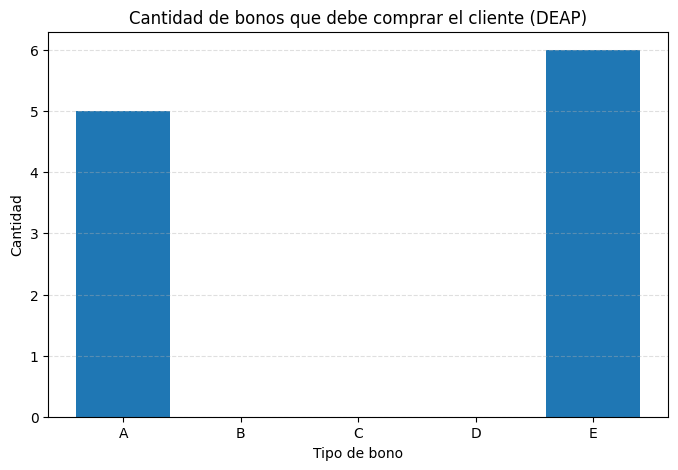

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(etiquetas, list(mejor_deap))
plt.title("Cantidad de bonos que debe comprar el cliente (DEAP)")
plt.xlabel("Tipo de bono")
plt.ylabel("Cantidad")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

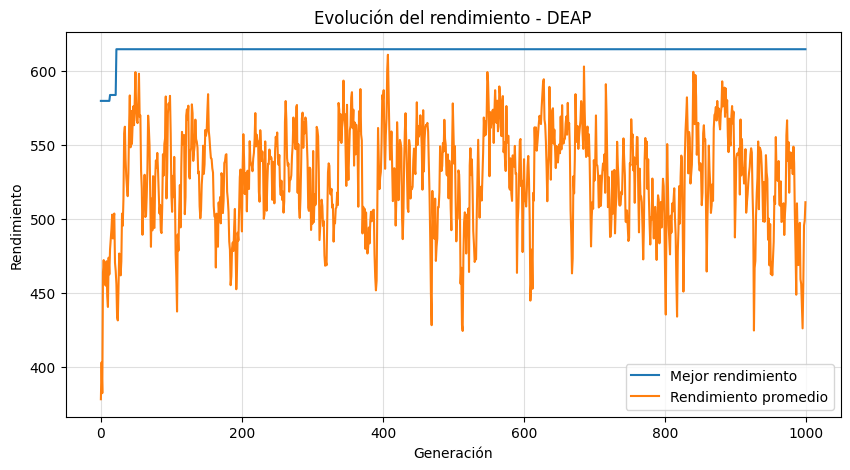

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(hist_mejor_deap, label="Mejor rendimiento")
plt.plot(hist_prom_deap, label="Rendimiento promedio")
plt.title("Evolución del rendimiento - DEAP")
plt.xlabel("Generación")
plt.ylabel("Rendimiento")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

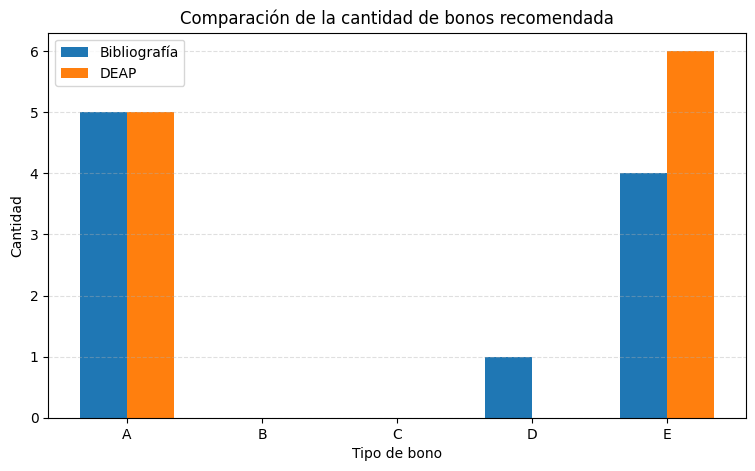

In [34]:
x = np.arange(len(etiquetas))
ancho = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - ancho/2, mejor_biblio, width=ancho, label="Bibliografía")
plt.bar(x + ancho/2, list(mejor_deap), width=ancho, label="DEAP")

plt.xticks(x, etiquetas)
plt.xlabel("Tipo de bono")
plt.ylabel("Cantidad")
plt.title("Comparación de la cantidad de bonos recomendada")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [36]:
print("============================================")
print("COMPARACIÓN ENTRE AMBOS CÓDIGOS")
print("============================================\n")

print("1. Diferencias en la programación de la función objetivo")
print("   - En ambos casos la función objetivo es la misma:")
print("     maximizar el rendimiento total de la inversión.")
print("   - En la bibliografía se calcula directamente con la función rendimiento(individuo).")
print("   - En DEAP esa misma función se encapsula dentro de evaluar_deap(individuo).")

print("\n2. Diferencias en la programación del fitness")
print("   - En la bibliografía el fitness se maneja de forma implícita mediante")
print("     el valor de rendimiento y el ordenamiento de la población.")
print("   - En DEAP el fitness se guarda en una estructura propia del individuo:")
print("     ind.fitness.values.")

print("\n3. Diferencias en la codificación de selección, cruza y mutación")
print("   - Bibliografía:")
print("       * Selección: lista de reproducción por ranking.")
print("       * Cruza: segmentación manual entre dos padres.")
print("       * Mutación: reemplazo manual de genes.")
print("   - DEAP:")
print("       * Selección: selRoulette.")
print("       * Cruza: cxOnePoint.")
print("       * Mutación: función personalizada registrada en toolbox.")

print("\n4. Resultados obtenidos")
print("   - Bibliografía:")
print("       Individuo:", mejor_biblio)
print("       Capital invertido:", capitalInvertido(mejor_biblio))
print("       Rendimiento:", rendimiento(mejor_biblio))

print("   - DEAP:")
print("       Individuo:", list(mejor_deap))
print("       Capital invertido:", capitalInvertido(mejor_deap))
print("       Rendimiento:", rendimiento(mejor_deap))

COMPARACIÓN ENTRE AMBOS CÓDIGOS

1. Diferencias en la programación de la función objetivo
   - En ambos casos la función objetivo es la misma:
     maximizar el rendimiento total de la inversión.
   - En la bibliografía se calcula directamente con la función rendimiento(individuo).
   - En DEAP esa misma función se encapsula dentro de evaluar_deap(individuo).

2. Diferencias en la programación del fitness
   - En la bibliografía el fitness se maneja de forma implícita mediante
     el valor de rendimiento y el ordenamiento de la población.
   - En DEAP el fitness se guarda en una estructura propia del individuo:
     ind.fitness.values.

3. Diferencias en la codificación de selección, cruza y mutación
   - Bibliografía:
       * Selección: lista de reproducción por ranking.
       * Cruza: segmentación manual entre dos padres.
       * Mutación: reemplazo manual de genes.
   - DEAP:
       * Selección: selRoulette.
       * Cruza: cxOnePoint.
       * Mutación: función personalizada re

## Conclusión

En este trabajo se resolvió el problema de asesoría de inversiones mediante dos enfoques: la solución basada en la bibliografía y la solución implementada con la librería **DEAP**. En ambos casos, el objetivo fue maximizar el rendimiento total de la inversión, respetando las restricciones del problema, es decir, el capital disponible y la cantidad máxima de bonos de cada tipo.

La principal diferencia entre ambos métodos se encuentra en la forma de programar el algoritmo genético. En la solución de la bibliografía, los operadores de selección, cruza y mutación fueron programados manualmente, lo que permite entender con mayor claridad la lógica interna del algoritmo. En cambio, con **DEAP** se utilizaron herramientas ya definidas por la librería, lo que hace el código más estructurado, reutilizable y fácil de ampliar.

Al comparar los resultados, se observó que ambos métodos son capaces de encontrar combinaciones de inversión con rendimientos altos y válidos dentro de las restricciones establecidas. Además, la representación gráfica permitió visualizar con claridad la cantidad de bonos que debe comprar el cliente para obtener el mejor rendimiento posible.

En conclusión, ambos enfoques cumplen con el objetivo del problema. La implementación manual resulta útil para comprender el funcionamiento de los algoritmos genéticos, mientras que la implementación con **DEAP** facilita su aplicación práctica y reduce la complejidad de programación.